In [1]:
# SYNTHETIC SCENE SETUP
import ivt
from ivt.scene import Scene, DiffuseBRDF, MicrofacetBRDF, Mesh, \
    PerspectiveCamera, HDRFilm, Integrator, EnvironmentLight
from ivt.io import read_image, read_mesh, write_image
from ivt.sampling import sample_sphere

from matplotlib import pyplot as plt
import torch
import numpy as np
from tqdm.notebook import tqdm

scene = Scene()

# material
SPECULAR=0.04
scene.set('mat', MicrofacetBRDF(0.3, SPECULAR, 0.3))
scene.set('mesh1', Mesh.from_file("assets/meshes/sphere.obj", 'mat')) # surface to reconstruct
scene.set('film', HDRFilm(256, 256))
scene.set('integrator', Integrator('collocated', {'intensity':1}))
# scene.set('cam1', PerspectiveCamera.from_lookat(fov=40, origin=(1,0.5,0), target=(0,0,0), up=(0,1,0))) # camera

# randomly generate cameras
num_sensors = 1
fov = 40
radius = 1
target = (0,0,0)
up = (0,1,0)
for i, origin in enumerate(sample_sphere(num_sensors, radius, 'fibonacci')):
    scene.set(f'sensor {i}', PerspectiveCamera.from_lookat(fov, origin, target, up))

# render target images
renderer = ivt.renderer.Renderer(connector_name='psdr_jit', render_options = {
    "spp": 16,
    "sppe": 0,
    "sppse": 0,
    "npass": 1,
    "log_level": 0
})
# because ivt has a glitch that doesn't update changes in spp, workaround here to render a higher spp target image
renders = torch.stack([renderer(scene, sensor_ids=range(num_sensors)) for _ in tqdm(range(100))])

  0%|          | 0/100 [00:00<?, ?it/s]

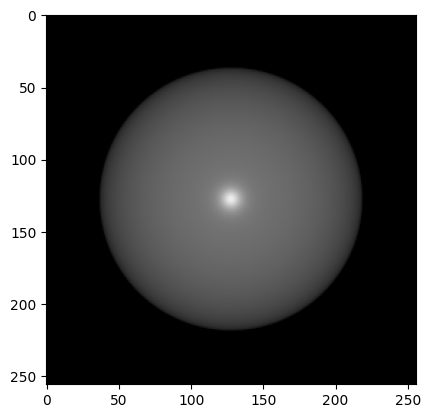

In [2]:
I_t = renders.mean(axis=0)
stddev = renders.std(axis=0)

# Visualize a target Image
def showimg(I):
    plt.imshow((I**0.454).detach().cpu().numpy().squeeze(), vmax=1)
showimg(I_t)

In [3]:
target = I_t[0,128,0:129,1]
target_dev = stddev[0,128,0:129,1]

In [4]:
# render images on D&R, fix S parameter combinations
from tqdm.notebook import tqdm
res = 80
Us = []
X, Z = np.mgrid[0+0.5/res:1-0.5/res:1j*res, 0+0.5/res:1-0.5/res:1j*res]
X = X.flatten().astype('float32')
Z = Z.flatten().astype('float32')
Y = np.full_like(X, SPECULAR)
I = []
for i in tqdm(range(len(X))):
    xo = torch.tensor([X[i], Y[i], Z[i]]).cuda()
    scene['mat']['d'] = xo[0]
    scene['mat']['s'] = xo[1]
    scene['mat']['r'] = xo[2]
    img = renderer(scene)
    I.append(img[0,128,0:129,1])
I = torch.vstack(I)

  0%|          | 0/6400 [00:00<?, ?it/s]

In [7]:
torch.save(I, "I8080.p")

In [8]:
from math import sqrt, pi
sigma = torch.tensor(0.05)
lpdf = (I - target).pow(2.0) / (2.0 * sigma.pow(2.0)) + (sigma*sqrt(2*pi)).log()

In [9]:
lpdf.min(), lpdf.max()

(tensor(-2.0768, device='cuda:0'), tensor(1.1942e+08, device='cuda:0'))

In [21]:
lpdf[...,3].reshape((res,res,-1)).shape

torch.Size([80, 80, 1])

In [65]:
px = 37

def plot_distr(px, expo=True):
    logp = -lpdf[..., px].reshape((res,res,-1)).sum(axis=-1)
    p = logp.exp() if expo else logp
    tensor = p.cpu().numpy()
#     a = np.quantile(tensor, 0.5)
#     print('min:', tensor.min(), 'max:', tensor.max())
    plt.imshow(tensor.T, extent=[0, 1, 0, 1], origin='lower', vmin=(0 if expo else None))
    plt.xlabel("Diffuse")
    plt.ylabel("Roughness")
    plt.colorbar()
    plt.scatter([0.3],[0.3], c="red")
    plt.title(f"posterior distribution from observing pixel {px}")
    plt.show()
    
    print(f"GT color @{px}: ", target[...,px].cpu().numpy())

In [66]:
print(target[...,100].cpu().numpy())

0.16155988


In [97]:
import ipywidgets as widgets
from IPython.display import display

slider_layout = widgets.Layout(width='80%')
slider = widgets.IntSlider(min=36, max=128, step=1, value=1, layout=slider_layout)
widgets.interactive(plot_distr, px=slider)

interactive(children=(IntSlider(value=36, description='px', layout=Layout(width='80%'), max=128, min=36), Chec…

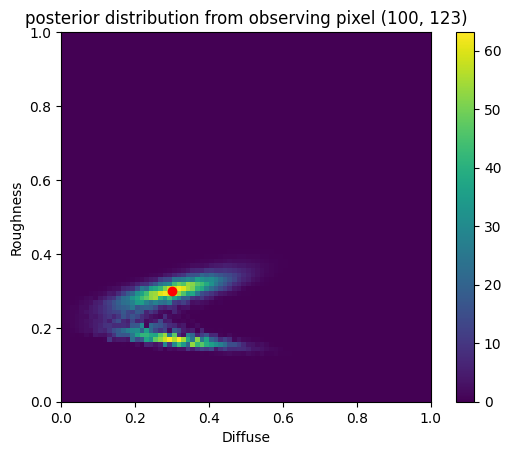

GT color @(100, 123):  [0.16155988 0.56932217]


In [96]:
plot_distr((100,123))

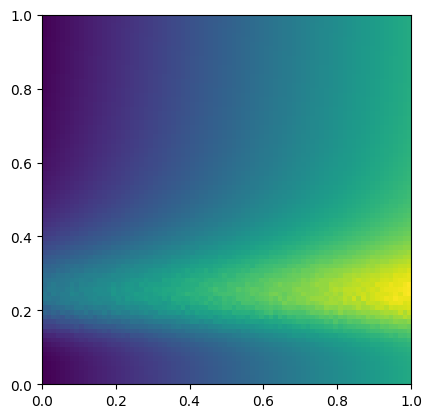

In [101]:
plt.imshow(I[...,122].reshape((res,res)).cpu().numpy().T, extent=[0, 1, 0, 1], origin="lower")